# Which Flash threats are best? (Powered Cube)

`Flash` cheats a big creature into play for two mana (then sacrifices it
unless you pay), so its payoff is a fatty whose **death / ETB value** lands
anyway — Worldspine Wurm (three 5/5s on death), Woodfall Primus (persist +
blow up a permanent), Archon of Cruelty, Atraxa, etc. Which threat is best?

Built on `lib17.decks` (deck-composition win-rate primitives). Several
framings, because "best Flash threat" is ambiguous:
1. **Raw**: GP WR of Flash decks that run each threat.
2. **Synergy lift**: does the threat win *more with Flash than without*?
3. **Density** (the main result): within Flash decks, WR by how many *other*
   big threats and *other* cheat enablers the deck runs — and whether those
   two axes are the same thing or separate levers.
4. **Special cases**: Abhorrent Oculus (a *cheap* creature Flash dodges the
   additional cost on, not a fatty) and Torsten (wants a graveyard shell?).

**Card set (curated).** Cheat-target fatties = Worldspine Wurm, Woodfall
Primus, Vaultborn Tyrant, Torsten, Atraxa, Archon of Cruelty, Griselbrand.
(Dropped Emrakul / Ulamog / Sundering Titan / Craterhoof as off-plan; *Sin,
Spira's Punishment* has no `deck_` column in this run — it wasn't played — so
it can't be analyzed.)

**Caveats.** GP WR is deck-level (a game counts if the card was maindecked) —
it carries deck-quality and pilot confounds; this is association, not
causation. Public cube logs cover **only the Nov-2025 run** (~266k games), so
this can't span sessions. Small cells (n ≲ 100) are noise — read n alongside
every WR. **And per-enabler "synergy" lifts are a trap** — see §5.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lib17 import decks, fetch
from lib17 import htmlfmt as H
plt.rcParams.update(H.MPL_STYLE)
pd.set_option("display.width", 230)
TAG = "cube"

names = decks.deck_card_names(TAG)
# curated cheat-target fatties (the threats we profile + count for redundancy)
BIG = [c for c in ["Worldspine Wurm", "Woodfall Primus", "Vaultborn Tyrant",
                   "Torsten, Founder of Benalia", "Atraxa, Grand Unifier",
                   "Archon of Cruelty", "Griselbrand"] if c in names]
# the cheat-into-play package (Flash itself is the anchor, excluded)
CHEAT = [c for c in ["Reanimate", "Animate Dead", "Necromancy", "Sneak Attack",
                     "Show and Tell", "Unburial Rites", "Natural Order",
                     "Persist", "Channel"] if c in names]
REANIM = [c for c in ["Reanimate", "Animate Dead", "Necromancy", "Unburial Rites"] if c in names]
PUTINTO = [c for c in ["Sneak Attack", "Show and Tell", "Natural Order"] if c in names]
n_flash, wr_flash = decks.wr(TAG, require=["Flash"])
print(f"{len(BIG)} threats, {len(CHEAT)} enablers: {CHEAT}")
print(f"Flash-deck universe: {n_flash} games, GP WR {wr_flash:.3f} (format mean ~0.545)")

7 threats, 9 enablers: ['Reanimate', 'Animate Dead', 'Necromancy', 'Sneak Attack', 'Show and Tell', 'Unburial Rites', 'Natural Order', 'Persist', 'Channel']
Flash-deck universe: 16724 games, GP WR 0.517 (format mean ~0.545)


## 1–2. Raw WR in Flash decks, and the synergy lift

`WR (+anchor)` = GP WR of Flash decks running the threat. `synergy lift` = that
minus the threat's WR in decks *without* Flash — positive means the card wins
more *with* Flash, a sign it's a genuine Flash payoff and not just a good card.

In [2]:
synergy = decks.cooccurrence_wr(TAG, "Flash", BIG, min_n=300)
display(synergy)

,card,n (+anchor),WR (+anchor),n (no anchor),WR (no anchor),synergy lift (pp)
0,Archon of Cruelty,3197,0.534,12486,0.526,0.8
1,"Atraxa, Grand Unifier",4644,0.533,11596,0.515,1.8
2,Worldspine Wurm,7053,0.532,4579,0.464,6.7
3,Woodfall Primus,5584,0.528,7381,0.470,5.8
4,Vaultborn Tyrant,3924,0.524,8706,0.498,2.6
5,Griselbrand,1931,0.517,10353,0.499,1.8
6,"Torsten, Founder of Benalia",5852,0.516,7096,0.491,2.5


Two different answers. **By raw WR in Flash decks**, Archon of Cruelty and
Atraxa top the list (~0.53) — but their **synergy lift is small**: they're
bomb-quality cards that win everywhere, Flash or not. **By synergy lift**,
Worldspine Wurm and Woodfall Primus are the standouts — they win ~46–47% in
fair decks but ~53% with Flash, because their death value is exactly what Flash
unlocks. *Best raw threat ≠ best Flash payoff.*

## 3–4. Within Flash decks: target redundancy vs enabler density

In [3]:
print("By # big threats in the deck (Flash decks):")
display(decks.count_bucket_wr(TAG, BIG, within=["Flash"]))
print("By # other cheat enablers (Flash decks):")
display(decks.count_bucket_wr(TAG, CHEAT, within=["Flash"]))

By # big threats in the deck (Flash decks):


,bucket,n,gp_wr
0,0,979,0.449
1,1,5229,0.511
2,2,5879,0.520
3,3+,4637,0.537


By # other cheat enablers (Flash decks):


,bucket,n,gp_wr
0,0,5492,0.501
1,1,5560,0.518
2,2,3662,0.536
3,3+,2010,0.526


Both help. A Flash deck with **zero** big threats is a misbuild (~0.43). Above
that, more threats and more enablers each raise WR — but are these *the same
lever* (dense decks just have more of everything) or *two separate levers*?
That's §6–7, and it's the crux of the question.

## 5. Why per-enabler "synergy lifts" are a mirage

It's tempting to build a threat × enabler matrix and read off "Reanimate is
Archon's best partner." **Don't.** Here's the disproof, baked into the data:
**Reanimate cannot target Worldspine Wurm** — the Wurm shuffles itself back in
from anywhere, including the graveyard, so it never sits there to be
reanimated. The interaction is *mechanically impossible*. Yet:

In [4]:
n_wr, w_wr = decks.wr(TAG, require=["Worldspine Wurm", "Reanimate"])
n_wo, w_wo = decks.wr(TAG, require=["Worldspine Wurm"], exclude=["Reanimate"])
print(f"Worldspine + Reanimate: n={n_wr}  WR={w_wr:.3f}")
print(f"Worldspine,  no Reanimate: n={n_wo}  WR={w_wo:.3f}")
print(f"apparent 'Reanimate synergy' on Worldspine: {(w_wr - w_wo) * 100:+.1f}pp  (mechanically impossible)")

Worldspine + Reanimate: n=1577  WR=0.521
Worldspine,  no Reanimate: n=10055  WR=0.502
apparent 'Reanimate synergy' on Worldspine: +1.9pp  (mechanically impossible)


The "lift" is **pure co-occurrence**: decks running both are just well-built
cheat decks where Worldspine is the *Flash/Show-and-Tell* target and Reanimate
is there for *other* bodies. The enabler didn't power the threat; a good deck
ran both. Every cell of a threat × enabler matrix has this confound, so a
positive cell tells you "good decks pair these," not "this enabler powers this
threat." The honest question isn't *which* enabler — it's **how dense** the
shell is, which §6–7 measure directly.

## 6. Are threat-density and enabler-density the same thing?

Intuition: "if you're super threat-dense you're probably also enabler-dense."
Test it — within Flash decks, correlate # big threats with # enablers.

In [5]:
import duckdb
rc = " + ".join(f'(({decks._present(c)}))::INT' for c in BIG)
cc = " + ".join(f'(({decks._present(c)}))::INT' for c in CHEAT)
fd = duckdb.connect().execute(
    f"SELECT ({rc}) AS n_big, ({cc}) AS n_enab, won::INT won "
    f"FROM '{decks._games(TAG)}' WHERE {decks._present('Flash')}").df()
print(f"corr(# threats, # enablers) within Flash decks: {fd.n_big.corr(fd.n_enab):.3f}  (n={len(fd)})")
print("\njoint counts (rows = # threats, cols = # enablers):")
display(pd.crosstab(fd.n_big.clip(upper=3), fd.n_enab.clip(upper=3)))

corr(# threats, # enablers) within Flash decks: 0.329  (n=16724)

joint counts (rows = # threats, cols = # enablers):


n_enab,0,1,2,3
n_big,,,,
0,517,248,151,63
1,2420,1715,778,316
2,1977,1947,1279,676
3,578,1650,1454,955


The premise is **partly true**: the correlation is **+0.33** — positive but
only moderate. Threat-dense decks *do* tend to be enabler-dense, but the two
are far from redundant (a 0.33 correlation leaves most of the variance
independent). So they *can* be separated, which is what the full grid does.

## 7. The full density matrix

GP WR of Flash decks by **both** axes at once: # big threats (rows) × #
enablers (cols). If the two were the same lever, WR would rise only along the
diagonal; if they're separate, WR rises along *both* independently.

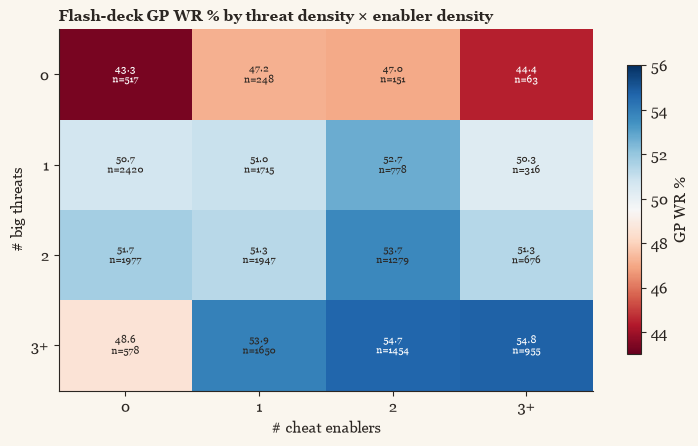

In [6]:
def heatmap(wrp, npv, title, ax, vmin=43, vmax=56):
    M = (wrp * 100).values.astype(float)
    im = ax.imshow(M, cmap="RdBu", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(wrp.shape[1])); ax.set_xticklabels(wrp.columns)
    ax.set_yticks(range(wrp.shape[0])); ax.set_yticklabels(wrp.index)
    for i in range(wrp.shape[0]):
        for j in range(wrp.shape[1]):
            v, n = M[i, j], npv.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.1f}\nn={int(n)}", ha="center", va="center",
                        fontsize=7, color="white" if abs(v - 50) > 4 else H.INK)
    ax.set_title(title, loc="left", fontweight="bold", fontsize=11)
    return im

wrp, npv = decks.count_grid_wr(TAG, BIG, CHEAT, within=["Flash"],
                               row_buckets=(1, 2, 3), col_buckets=(1, 2, 3))
fig, ax = plt.subplots(figsize=(7.5, 4.6))
im = heatmap(wrp, npv, "Flash-deck GP WR % by threat density × enabler density", ax)
ax.set_xlabel("# cheat enablers"); ax.set_ylabel("# big threats")
fig.colorbar(im, ax=ax, shrink=0.8, label="GP WR %")
plt.tight_layout(); plt.show()

**Two separate levers, and they stack.** WR climbs left-to-right (more
enablers) at every threat count, and top-to-bottom (more threats) at every
enabler count. The worst cell is row 0 (a Flash deck with no fatty to cheat —
a misbuild, ~0.43). The best cell is the **bottom-right corner — 3+ threats
*and* 3+ enablers, ~0.55** (n≈955, solid). You want a deck dense in *both*:
enough targets that you always have one, enough enablers that you always have
the cheat. Neither alone gets you to the corner.

## 8. Archon and the "best reanimator target" intuition

Claim: *Archon is best specifically in threat-dense Flash decks, because it's
the best reanimator card.* Two ways to test it. First, the same grid but
restricted to **Flash decks that run Archon** — does Archon's WR climb with
*other* threats, with enablers, or both?

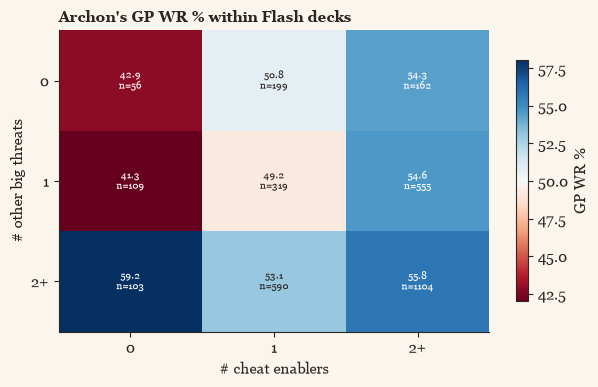

In [7]:
oth = [b for b in BIG if b != "Archon of Cruelty"]
wa, na = decks.count_grid_wr(TAG, oth, CHEAT, within=["Flash", "Archon of Cruelty"],
                             row_buckets=(1, 2), col_buckets=(1, 2))
fig, ax = plt.subplots(figsize=(6.2, 4))
im = heatmap(wa, na, "Archon's GP WR % within Flash decks", ax, vmin=42, vmax=58)
ax.set_xlabel("# cheat enablers"); ax.set_ylabel("# other big threats")
fig.colorbar(im, ax=ax, shrink=0.8, label="GP WR %")
plt.tight_layout(); plt.show()

Second, **disentangle with a regression** — within Flash + Archon decks, fit
`won ~ #other_threats + #enablers`. The coefficients are the effect of each
axis *holding the other fixed*, which the raw grid can't isolate.

In [8]:
oc = " + ".join(f'(({decks._present(b)}))::INT' for b in oth)
da = duckdb.connect().execute(
    f"SELECT ({oc}) AS n_oth, ({cc}) AS n_en, won::INT won FROM '{decks._games(TAG)}' "
    f"WHERE {decks._present('Flash')} AND {decks._present('Archon of Cruelty')}").df()
X = np.column_stack([np.ones(len(da)), da["n_oth"].values, da["n_en"].values])
b, *_ = np.linalg.lstsq(X, da.won.values, rcond=None)
print(f"n={len(da)} Flash+Archon games")
print(f"  baseline WR        {b[0]:.3f}")
print(f"  per extra threat   {b[1] * 100:+.2f}pp  (holding enablers fixed)")
print(f"  per extra enabler  {b[2] * 100:+.2f}pp  (holding threats fixed)")

n=3197 Flash+Archon games
  baseline WR        0.477
  per extra threat   +1.63pp  (holding enablers fixed)
  per extra enabler  +1.68pp  (holding threats fixed)


**The intuition is half-right.** Archon's WR rises with threat density *and*
with enabler density — and the regression shows they're **near-equal,
independent levers** (≈ **+1.6pp per threat, +1.7pp per enabler**, each holding
the other fixed). So threat-density is a real, separate benefit for Archon —
*not* just a proxy for enablers (consistent with the modest 0.33 correlation).
But it isn't a *special* Archon thing: every ETB body gains the same way.

**Is Archon the *best* in the dense corner?** Each threat's WR in dense Flash
decks (2+ other threats **and** 2+ enablers) vs everywhere else:

In [9]:
rows = []
for c in BIG:
    others = [b for b in BIG if b != c]
    oc2 = " + ".join(f'(({decks._present(b)}))::INT' for b in others)
    d = duckdb.connect().execute(
        f"SELECT ({oc2}) AS n_oth, ({cc}) AS n_en, won::INT won FROM '{decks._games(TAG)}' "
        f"WHERE {decks._present('Flash')} AND {decks._present(c)}").df()
    dense = d[(d.n_oth >= 2) & (d.n_en >= 2)]; sparse = d[~((d.n_oth >= 2) & (d.n_en >= 2))]
    rows.append({"threat": c.split(",")[0], "n dense": len(dense), "WR dense": round(dense.won.mean(), 3),
                 "WR sparse": round(sparse.won.mean(), 3),
                 "dense lift pp": round((dense.won.mean() - sparse.won.mean()) * 100, 1)})
display(pd.DataFrame(rows).sort_values("WR dense", ascending=False).reset_index(drop=True))

,threat,n dense,WR dense,WR sparse,dense lift pp
0,Archon of Cruelty,1104,0.558,0.522,3.6
1,Griselbrand,851,0.553,0.488,6.6
2,Woodfall Primus,1189,0.549,0.523,2.7
3,Vaultborn Tyrant,929,0.548,0.517,3.1
4,Atraxa,1292,0.545,0.528,1.7
5,Worldspine Wurm,1329,0.544,0.529,1.5
6,Torsten,1364,0.544,0.508,3.6


Archon *does* have the **top WR in the dense corner (0.558)** — so the
intuition isn't wrong — but it's a **near-tie** with Griselbrand (0.553),
Woodfall (0.549) and Vaultborn (0.548); the spread is inside the noise for
n≈1000. The sharper story is **Griselbrand**: it has the **largest dense lift
(+6.6pp)** because it's *worst* in sparse decks (0.488) — it's the threat that
most *needs* the dense shell, even if Archon edges it at the top. Takeaway:
the dense reanimator shell lifts *all* the ETB bodies; Archon is the best of a
tight pack, not a standout.

## 9. Abhorrent Oculus — the cheap creature Flash *dodges a cost* on

Oculus (MV 3) isn't a fatty — it's a 5/5 flyer whose real price is an
*additional cost* (exile six cards from your graveyard). Flash puts it onto
the battlefield without *casting* it, so it **skips that additional cost** — a
different Flash interaction than the death-trigger fatties. Does it help?

In [10]:
rows = []
for lbl, req, exc in [("Oculus (all)", ["Abhorrent Oculus"], []),
                      ("Oculus + Flash", ["Abhorrent Oculus", "Flash"], []),
                      ("Oculus, no Flash", ["Abhorrent Oculus"], ["Flash"])]:
    n, w = decks.wr(TAG, require=req, exclude=exc)
    rows.append({"deck": lbl, "n": n, "GP WR": round(w, 3)})
display(pd.DataFrame(rows))

,deck,n,GP WR
0,Oculus (all),10677,0.521
1,Oculus + Flash,1082,0.516
2,"Oculus, no Flash",9595,0.521


**The cute line doesn't pay.** Oculus wins ~0.521 whether or not the deck runs
Flash, and Oculus+Flash is if anything a hair *lower* (0.516, n=1082). Oculus
is already cheap and graveyard decks pay its additional cost happily, so
dodging it with Flash buys nothing — and it competes for the Flash you'd rather
point at a real fatty. Oculus is a fine card; it is **not** a Flash payoff.

## 10. Torsten — does it want a reanimation (graveyard) shell?

Theory: Torsten rewards a graveyard full of creatures, so the
Reanimate / Animate Dead style enablers suit it better than the
put-into-play enablers (Sneak Attack / Show and Tell / Natural Order). Within
Flash + Torsten decks, WR by count of each package:

In [11]:
print("reanimation package (Reanimate / Animate Dead / Necromancy / Unburial Rites):")
display(decks.count_bucket_wr(TAG, REANIM, within=["Flash", "Torsten, Founder of Benalia"], buckets=(1, 2)))
print("put-into-play package (Sneak Attack / Show and Tell / Natural Order):")
display(decks.count_bucket_wr(TAG, PUTINTO, within=["Flash", "Torsten, Founder of Benalia"], buckets=(1, 2)))

reanimation package (Reanimate / Animate Dead / Necromancy / Unburial Rites):


,bucket,n,gp_wr
0,0,3372,0.502
1,1,1533,0.530
2,2+,947,0.542


put-into-play package (Sneak Attack / Show and Tell / Natural Order):


,bucket,n,gp_wr
0,0,3553,0.513
1,1,1963,0.523
2,2+,336,0.512


**Directionally consistent with the theory.** Torsten's WR rises with the
reanimation package (0.502 → 0.530 → 0.542) but is flat-to-down with the
put-into-play package (0.513 → 0.523 → 0.512). A graveyard shell tracks Torsten
wins; a Sneak/Show shell doesn't. **But** — recall §5 — these are
co-occurrence gradients, and reanimation-density also proxies overall enabler
density. So read it as *support for*, not *proof of*, the mechanism: the clean
claim is that Torsten lives in dense graveyard decks, not that any one
reanimation spell powers it.

## Verdict

- **Best Flash payoffs** (win much more with Flash than without): **Worldspine
  Wurm** and **Woodfall Primus** — their death triggers are what Flash buys, and
  Worldspine is also the most standalone-robust.
- **Best raw cards in a Flash deck**: **Archon** and **Atraxa** — bombs you'd
  run anyway; they barely need Flash.
- **The lever that matters is density, on *two separate axes***: threats and
  enablers each add ~+1.6–1.7pp independently (they correlate only +0.33). The
  best decks sit in the dense corner — 3+ targets *and* 3+ enablers (~0.55).
- **Archon in dense decks**: the intuition holds *weakly* — Archon has the top
  dense-corner WR but in a near-tie; **Griselbrand** is the threat that most
  *needs* the dense shell. Threat-density is a real benefit, not just an
  enabler-density proxy — but it's not unique to Archon.
- **Abhorrent Oculus**: not a Flash payoff — dodging its additional cost with
  Flash is WR-neutral. **Torsten**: directionally wants a graveyard shell.
- **Don't trust per-enabler synergy lifts** (§5): Reanimate appears to "lift"
  Worldspine despite being unable to target it — the lifts are co-occurrence.

All GP WR, Nov-2025 cube run, deck-level association — see caveats up top.